# Full Diffusion MRI Pipeline (Multi-level Degradation)

In [1]:
import torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os
from scipy.io import loadmat
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
class MRIDataset(Dataset):
    def __init__(self, root_dir):
        self.images = []

        print("Carregando dataset...")

        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.endswith(".mat"):
                    path = os.path.join(root, f)
                    data = loadmat(path)

                    if "x" not in data:
                        continue

                    x = data["x"]

                    for i in range(x.shape[2]):
                        img = x[:, :, i]

                        img = (img - img.min())/(img.max() - img.min() + 1e-8)

                        self.images.append(img.astype(np.float32))

        print("Total imagens:", len(self.images))

    def __getitem__(self, idx):
        x = torch.tensor(self.images[idx]).float()

        x = (x - x.mean())/(x.std() + 1e-8)

        x = x.unsqueeze(0).unsqueeze(0)   

        x = F.interpolate(x, size=(256,256), mode='bilinear', align_corners=False)

        x = x.squeeze(0)   

        return x

    def __len__(self):
        return len(self.images)

In [3]:
dataset_path = "/kaggle/input/datasets/semnickcharlie/brain-dataset1"
dataset = MRIDataset(dataset_path)

loader = DataLoader(dataset, batch_size=4, shuffle=True)

Carregando dataset...
Total imagens: 4020


In [4]:
def fft2(x):
    return torch.fft.fft2(x)

def ifft2(k):
    return torch.fft.ifft2(k).real

def to_kspace(x):
    return torch.view_as_real(fft2(x))

def to_image(k):
    return ifft2(torch.view_as_complex(k))

In [5]:
def create_mask_t(shape, t, T, device):
    H, W = shape

    accel = 1 + (t / T) * 3

    mask = torch.zeros(H, W, device=device)

    center = H // 2
    num_low = int(H * 0.08)

    mask[center-num_low//2:center+num_low//2, :] = 1

    prob = 1 / accel

    for i in range(H):
        if torch.rand(1, device=device) < prob:
            mask[i, :] = 1

    return mask


In [6]:
def degrade_kspace(x, t, T):

    k_complex = fft2(x)

    mask = create_mask_t(k_complex.shape[-2:], t, T, x.device)

    k_t = k_complex * mask

    x_t = ifft2(k_t)

    k_t_real = torch.view_as_real(k_t)

    return x_t, k_t_real, mask


In [7]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.Linear(1,128),
            nn.ReLU(),
            nn.Linear(128,256)
        )

        self.conv1 = nn.Conv2d(1,64,3,padding=1)
        self.conv2 = nn.Conv2d(64,128,3,padding=1)
        self.conv3 = nn.Conv2d(128,256,3,padding=1)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.ConvTranspose2d(256,128,2,2)

        self.conv4 = nn.Conv2d(128+64,128,3,padding=1)
        self.out = nn.Conv2d(128,1,1)

    def forward(self,x,t):
        t = t.view(-1,1)
        t_embed = self.time_mlp(t).view(-1,256,1,1)

        e1 = F.relu(self.conv1(x))
        e2 = F.relu(self.conv2(self.pool(e1)))

        b = F.relu(self.conv3(e2) + t_embed)

        d = self.up(b)
        d = torch.cat([d,e1],1)
        d = F.relu(self.conv4(d))

        return self.out(d)


model = UNet().to(device)


In [8]:
def data_consistency(x, k_obs, mask):

    k = fft2(x)

    k = mask * k_obs + (1-mask) * k

    return ifft2(k)

In [9]:
def train(model, loader, epochs=15, T_max=50):

    opt = torch.optim.Adam(model.parameters(), 1e-4)

    for epoch in range(epochs):
        print("\nEpoch", epoch)
        total_loss = 0

        for i, x in enumerate(loader):

            x = x.to(device)

            t = torch.randint(1, T_max, (x.shape[0],), device=device)
            t_norm = t.float() / T_max

            x_t_list = []

            for b in range(x.shape[0]):
                x_t, _, _ = degrade_kspace(x[b], t[b], T_max)
                x_t_list.append(x_t)

            x_t = torch.stack(x_t_list)  

            pred = model(x_t, t_norm)

            loss = ((pred.squeeze() - x)**2).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()

            if i % 500 == 0:
                print("batch", i)

        print("Loss:", total_loss / len(loader))

In [10]:
def reconstruct(model, x, T_max=50):

    x = x.to(device)

    _, k_obs_real, mask_full = degrade_kspace(x, T_max, T_max)

    k_obs = torch.view_as_complex(k_obs_real)

    x_t = ifft2(k_obs)
    x_t = x_t.unsqueeze(0).unsqueeze(0)  # [1,1,H,W]

    for t_step in reversed(range(1, T_max)):

        t_tensor = torch.tensor([t_step / T_max], device=device)

        x_t = x_t.squeeze()
        x_t = x_t.unsqueeze(0).unsqueeze(0)

        x0_hat = model(x_t, t_tensor)

        x0_img = x0_hat.squeeze()

        k_hat = fft2(x0_img)

        mask_t = create_mask_t(k_hat.shape[-2:], t_step, T_max, device)
        mask_prev = create_mask_t(k_hat.shape[-2:], t_step-1, T_max, device)

        D_t = ifft2(k_hat * mask_t)
        D_prev = ifft2(k_hat * mask_prev)

        x_t = x_t.squeeze() - D_t + D_prev

        x_t = data_consistency(x_t, k_obs, mask_full)

        x_t = x_t.unsqueeze(0).unsqueeze(0)

    return x_t



Epoch 0
batch 0
batch 500
batch 1000
Loss: 0.6172705072965194


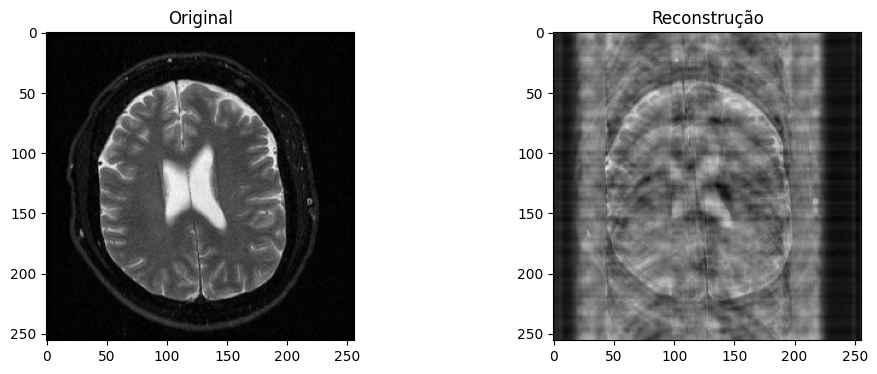

In [11]:
train(model, loader, epochs=1)

x = dataset[10]
recon = reconstruct(model, x)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(x.squeeze().numpy(), cmap='gray')

plt.subplot(1,2,2)
plt.title("Reconstrução")
plt.imshow(recon.squeeze().detach().cpu().numpy(), cmap='gray')

plt.show()